In [10]:
# Berlin Food Delivery ETA Prediction
## Setup & Initial Data Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

%matplotlib inline

In [13]:
train = pd.read_csv('/Users/akashkumarsamantray/berlin-food-delivery-eta-prediction/berlin-food-delivery-eta-prediction/Data/train.csv')
test = pd.read_csv('/Users/akashkumarsamantray/berlin-food-delivery-eta-prediction/berlin-food-delivery-eta-prediction/Data/test.csv')
sample_sub = pd.read_csv('/Users/akashkumarsamantray/berlin-food-delivery-eta-prediction/berlin-food-delivery-eta-prediction/Data/Sample_Submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample submission shape: {sample_sub.shape}")

Train shape: (45593, 20)
Test shape:  (11399, 19)
Sample submission shape: (11399, 2)


In [14]:
train.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [16]:
## Missing Values

# Standard nulls
print("Standard nulls:\n", train.isnull().sum()[train.isnull().sum() > 0])

# Literal string 'NaN' hiding in object columns
print("\nLiteral 'NaN' strings per column:")
for col in train.select_dtypes(include='object').columns:
    cnt = train[col].astype(str).str.strip().eq('NaN').sum()
    if cnt > 0:
        print(f"  {col}: {cnt} ({cnt/len(train)*100:.1f}%)")

Standard nulls:
 Series([], dtype: int64)

Literal 'NaN' strings per column:
  Delivery_person_Age: 1854 (4.1%)
  Delivery_person_Ratings: 1908 (4.2%)
  Time_Orderd: 1731 (3.8%)
  Road_traffic_density: 601 (1.3%)
  multiple_deliveries: 993 (2.2%)
  Festival: 228 (0.5%)
  City: 1200 (2.6%)


In [17]:
## Target Column

print(train['Time_taken(min)'].unique()[:10])

['(min) 24' '(min) 33' '(min) 26' '(min) 21' '(min) 30' '(min) 40'
 '(min) 32' '(min) 34' '(min) 46' '(min) 23']


In [ ]:
## Step 2: Data Cleaning

## Fixing the issues identified in Step 1:
 #Target column has text mixed with numbers
 #Categorical columns have extra whitespace and prefixes
 #Missing values are stored as literal "NaN" strings, not true NaN
 #Age/Ratings are stored as text instead of numbers

In [18]:
## Cleaned the target column

# Time_taken(min) looks like "(min) 24" -> extracted just the number
train['Time_taken(min)'] = train['Time_taken(min)'].astype(str).str.extract(r'(\d+)').astype(float)

print(train['Time_taken(min)'].describe())

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [19]:
## Replaced literal 'NaN' strings with real NaN

def clean_nan_strings(df):
    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace('NaN', np.nan)
    return df

train = clean_nan_strings(train)
test = clean_nan_strings(test)

print(train.isnull().sum()[train.isnull().sum() > 0])

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200
dtype: int64


In [20]:
## Striped prefixes from categorical columns

# Weatherconditions looks like "conditions Sunny" -> just "Sunny"
train['Weatherconditions'] = train['Weatherconditions'].str.replace('conditions ', '', regex=False)
test['Weatherconditions'] = test['Weatherconditions'].str.replace('conditions ', '', regex=False)

print(train['Weatherconditions'].unique())

['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' 'NaN']


In [21]:
## Converted numeric-looking text columns to actual numbers

numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']

for col in numeric_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

train[numeric_cols].dtypes

Delivery_person_Age        float64
Delivery_person_Ratings    float64
multiple_deliveries        float64
dtype: object

In [22]:
## Checked remaining missing values after cleaning

missing_summary = train.isnull().sum()
missing_pct = (missing_summary / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
Delivery_person_Ratings,1908,4.18
Delivery_person_Age,1854,4.07
Time_Orderd,1731,3.80
City,1200,2.63
multiple_deliveries,993,2.18
Road_traffic_density,601,1.32
Festival,228,0.50


In [23]:
## Imputed missing values

# Numeric columns: fill with median
for col in ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# Categorical columns: fill with mode
categorical_to_impute = ['Road_traffic_density', 'Festival', 'City']
for col in categorical_to_impute:
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)

print("Remaining nulls:\n", train.isnull().sum()[train.isnull().sum() > 0])

Remaining nulls:
 Time_Orderd    1731
dtype: int64


In [24]:
train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30.0


In [ ]:
## Step 3: Exploratory Data Analysis

# Goal: Understanding the distribution of delivery time and how it relates to weather, traffic, vehicle type, and delivery person attributes — before 
# We engineer new features.

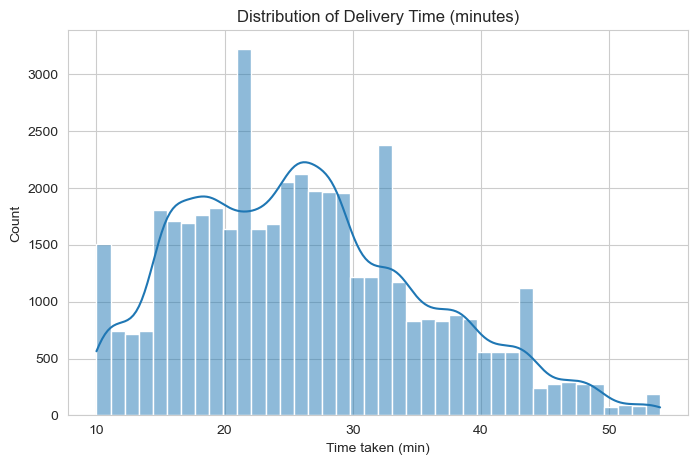

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64


In [25]:
## Target variable distribution graph

plt.figure(figsize=(8, 5))
sns.histplot(train['Time_taken(min)'], bins=40, kde=True)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Time taken (min)')
plt.ylabel('Count')
plt.show()

print(train['Time_taken(min)'].describe())

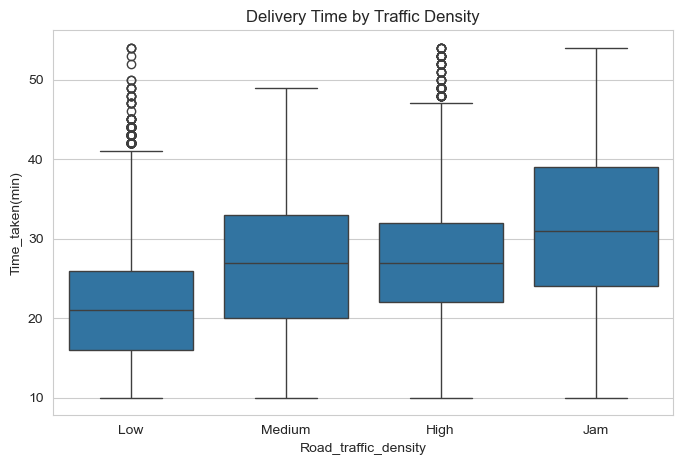

In [26]:
## Delivery time by traffic density

plt.figure(figsize=(8, 5))
order = ['Low', 'Medium', 'High', 'Jam']
sns.boxplot(data=train, x='Road_traffic_density', y='Time_taken(min)', order=order)
plt.title('Delivery Time by Traffic Density')
plt.show()

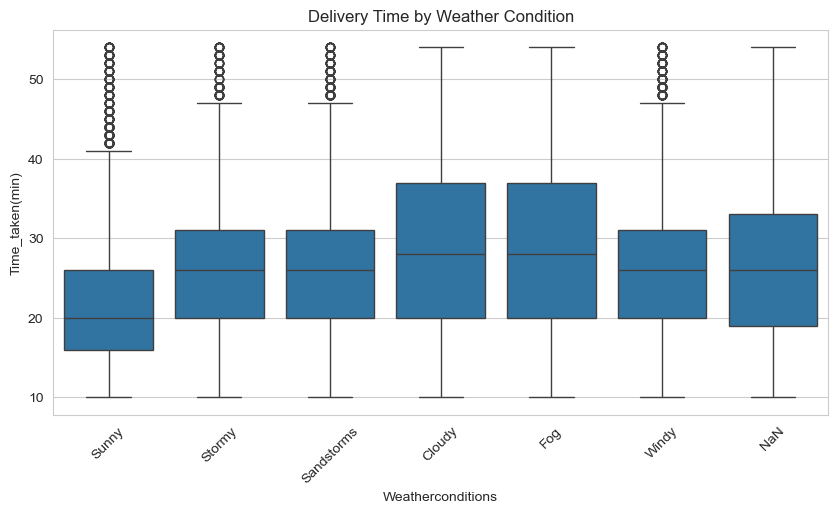

In [27]:
## delivery time by weather condition

plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='Weatherconditions', y='Time_taken(min)')
plt.title('Delivery Time by Weather Condition')
plt.xticks(rotation=45)
plt.show()

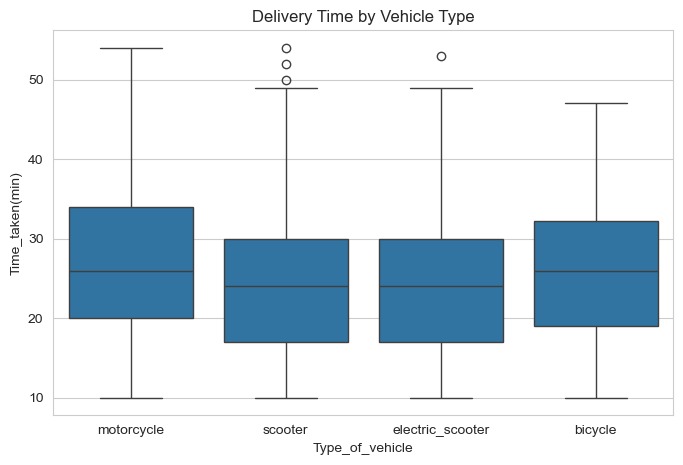

In [28]:
## delivery time by vehicle type

plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='Type_of_vehicle', y='Time_taken(min)')
plt.title('Delivery Time by Vehicle Type')
plt.show()

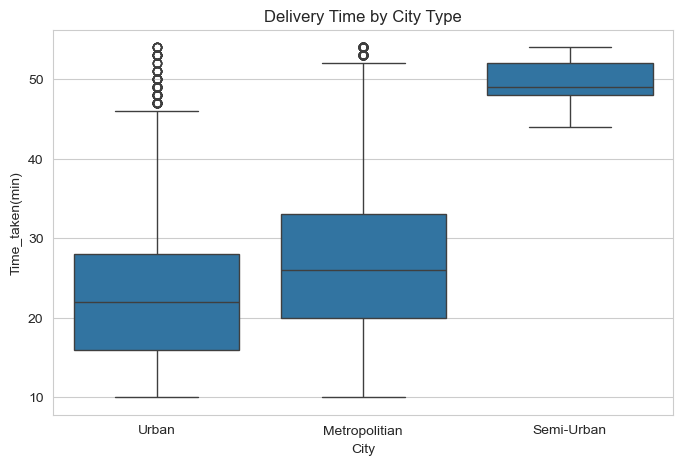

In [30]:
## delivery time by city type

plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='City', y='Time_taken(min)')
plt.title('Delivery Time by City Type')
plt.show()

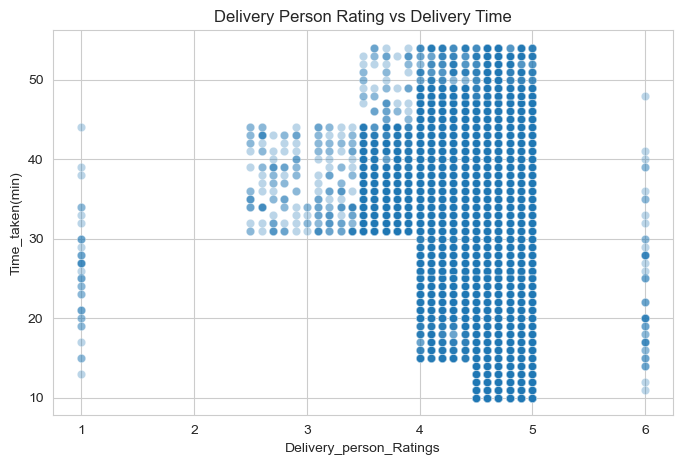

In [31]:
## delivery person rating vs delivery time

plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x='Delivery_person_Ratings', y='Time_taken(min)', alpha=0.3)
plt.title('Delivery Person Rating vs Delivery Time')
plt.show()

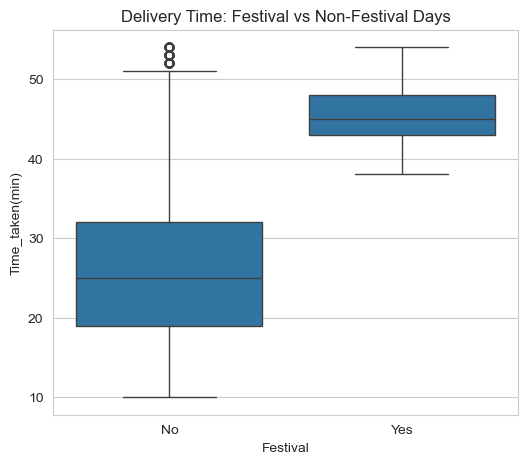

In [33]:
## festival effect

plt.figure(figsize=(6, 5))
sns.boxplot(data=train, x='Festival', y='Time_taken(min)')
plt.title('Delivery Time: Festival vs Non-Festival Days')
plt.show()

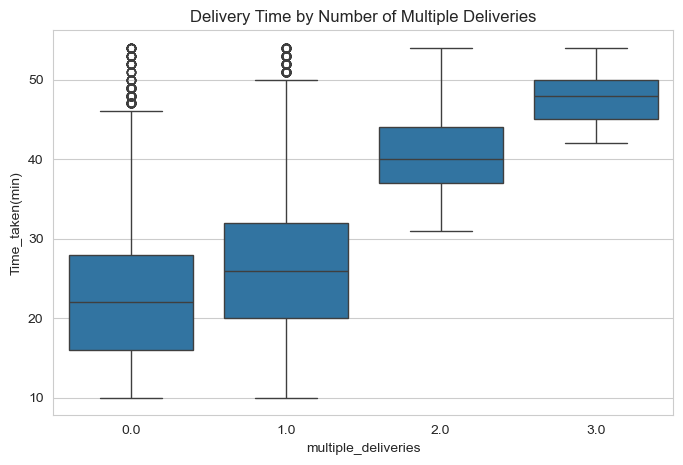

In [34]:
## multiple deliveries effect

plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='multiple_deliveries', y='Time_taken(min)')
plt.title('Delivery Time by Number of Multiple Deliveries')
plt.show()

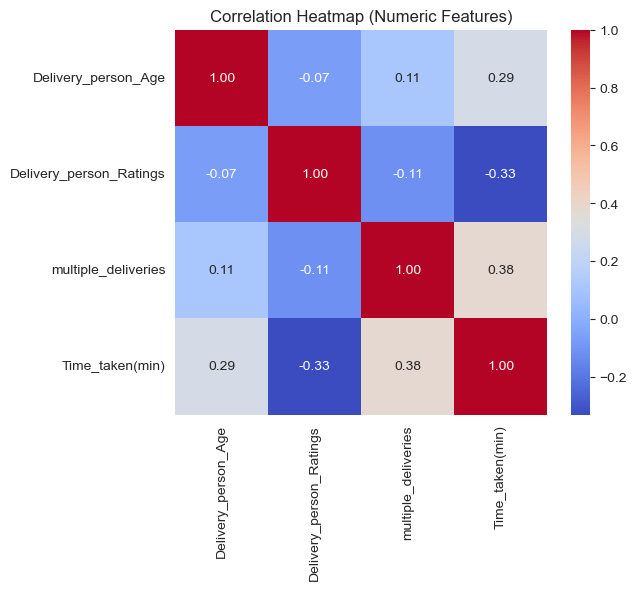

In [36]:
## correlation heatmap for numeric columns
numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
                 'multiple_deliveries', 'Time_taken(min)']
plt.figure(figsize=(6, 5))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


In [37]:
## Exported cleaned data for Feature Engineering

train.to_csv('train_cleaned.csv', index=False)
test.to_csv('test_cleaned.csv', index=False)
print("Saved train_cleaned.csv and test_cleaned.csv for feature engineering notebook")

Saved train_cleaned.csv and test_cleaned.csv for feature engineering notebook
